In [ ]:
## Importing Libraries

In this step, I import all the necessary libraries required for data analysis, 
visualisation, and model development. Pandas and NumPy are used for data manipulation, 
while Matplotlib and Seaborn are used for visualisation.
I also import the required machine learning tools from Scikit-learn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

In [ ]:
## Loading the Dataset

In this step, I load the insurance dataset into a Pandas DataFrame and preview the first few rows to understand the structure of the data.

In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
## Understanding the Dataset

I examine the structure and statistical summary of the dataset. 
This helps me understand the data types, number of entries, and general distribution of the variables.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
## Checking for Missing Values

I check whether the dataset contains any missing values. This is important because missing data can affect the accuracy of the model.

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
## Data Visualisation

In this section, I create visualisations to better understand the distribution of the data and the relationships between variables.
These visuals will also help guide my model development.

In [ ]:
### Histogram of Medical Charges

I use a histogram to analyse the distribution of the target variable. 
This helps me understand how medical charges are spread across individuals and 
whether outliers are present.

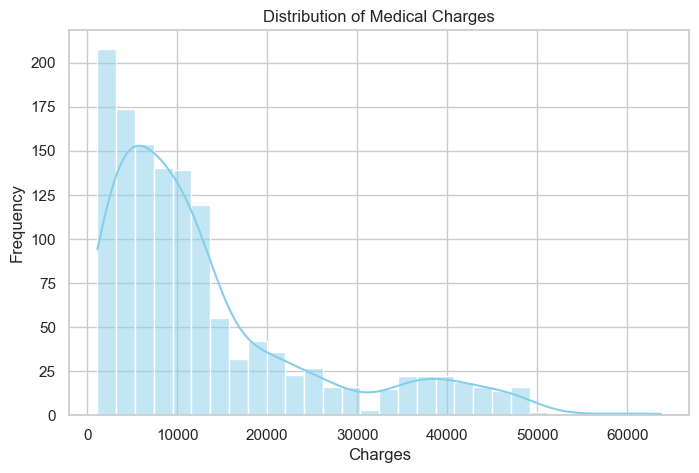

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True, color='skyblue')
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [ ]:
### Correlation Heatmap

I used a heatmap to examine the relationships between numerical variables. 
This helps identify which features are strongly related to medical charges.


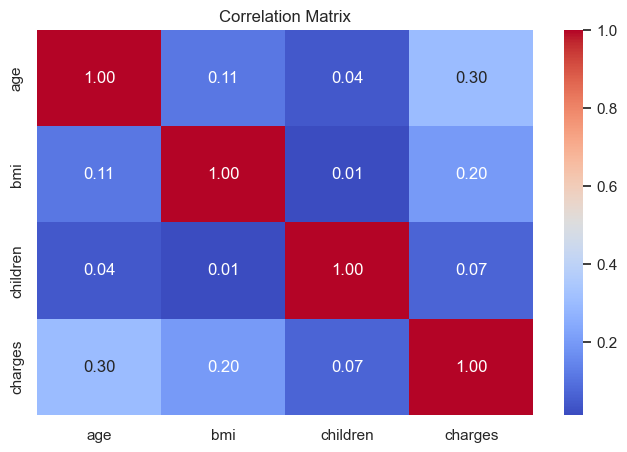

In [12]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
### Relationship Between Age and Medical Charges

I use a scatterplot to analyse the relationship between age and medical charges. I include colour coding based on smoking 
status to clearly distinguish between smokers and non smokers.
The visualisation shows a positive relationship between age and charges.
It also highlights that smokers tend to incur higher costs than non smokers across all age groups.


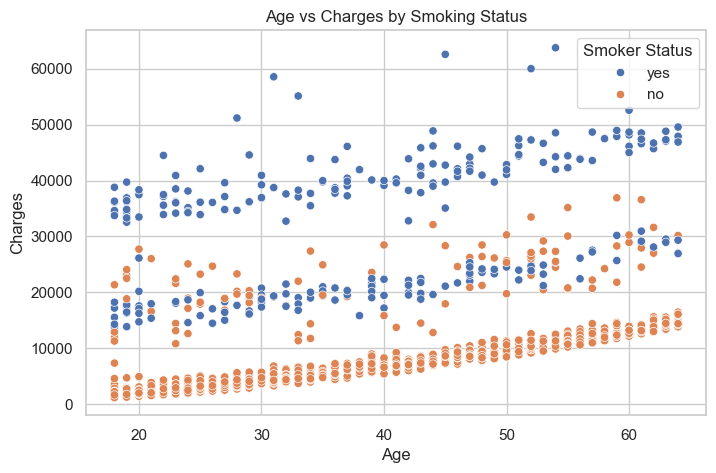

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(title="Smoker Status")
plt.show()

In [ ]:
### Medical Charges by Smoking Status

I use a boxplot to compare the distribution of medical charges between smokers and non smokers.
Each category is represented by a different colour to improve clarity.
The results show a clear difference between the two groups. Smokers have significantly 
higher charges and greater variability compared to non smokers.



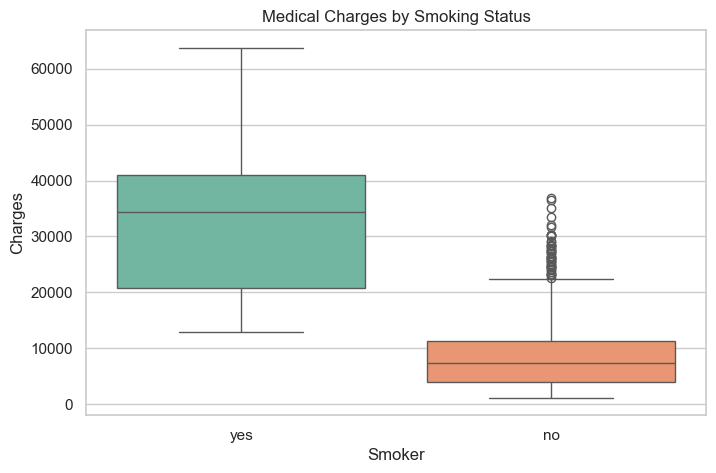

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', hue='smoker', data=df, palette='Set2', legend=False)
plt.title("Medical Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

In [ ]:
### Medical Charges by Region

I use a boxplot to compare medical charges across different regions. 
Each region is represented using a different colour to make comparisons easier.
The variation across regions is relatively small, suggesting that geographic location has a weaker influence on charges
compared to factors such as smoking and age.

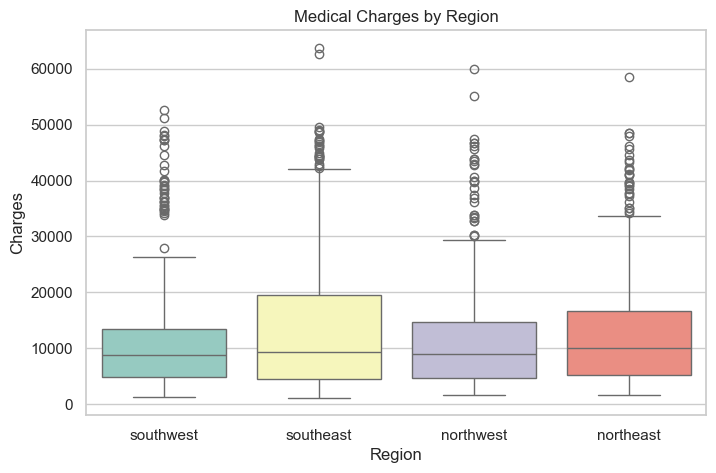

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', hue='region', data=df, palette='Set3', legend=False)
plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

In [ ]:
## Feature Engineering

In this step, I convert categorical variables into numerical format using one hot encoding.
This is necessary because machine learning models require numerical input.

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
## Defining Features and Target

I separate the dataset into independent variables and the target variable.
The target variable is charges, while the remaining variables are used as features.

In [22]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [ ]:
## Splitting the Data

I split the dataset into training and testing sets.
This allows me to train the model on one portion of the data and evaluate it on unseen data.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
## Training the Model

I train a Linear Regression model using the training data.
This model will learn the relationship between the features and the target variable.

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
## Analysing Model Coefficients

I examine the coefficients of the model to understand how each feature influences medical charges.

In [25]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients

,Coefficient
age,256.975706
bmi,337.092552
children,425.278784
sex_male,-18.591692
smoker_yes,23651.128856
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


In [ ]:
## Making Predictions

I use the trained model to predict medical charges on the test dataset.

In [29]:
y_pred = model.predict(X_test)

In [ ]:
## Evaluating the Model

I evaluate the performance of the model using MAE, RMSE, and R squared. These metrics help me understand how accurate the model is.

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4181.194473753654
RMSE: 5796.2846592762735
R2 Score: 0.7835929767120723


In [ ]:
## Actual vs Predicted Plot

I create a scatterplot comparing actual values and predicted values. This helps me visually assess how well the model performs.

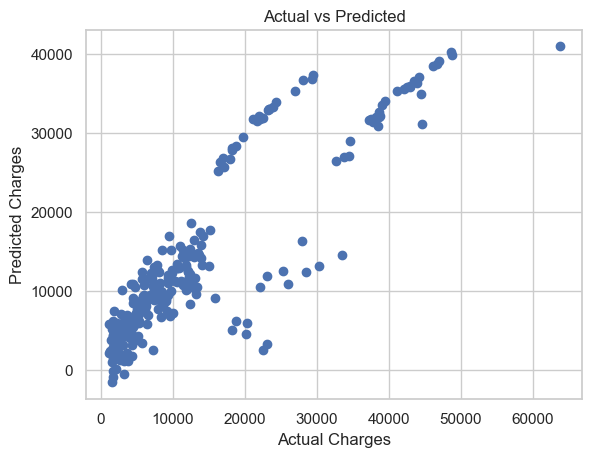

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
## Model Improvement

I improve the model by removing extreme outliers from the dataset and retraining the model. This helps improve prediction accuracy.

In [28]:
threshold = df_encoded['charges'].quantile(0.99)
df_filtered = df_encoded[df_encoded['charges'] < threshold]

X2 = df_filtered.drop('charges', axis=1)
y2 = df_filtered['charges']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2_2 = r2_score(y_test2, y_pred2)

print("Improved MAE:", mae2)
print("Improved RMSE:", rmse2)
print("Improved R2:", r2_2)

Improved MAE: 4014.638679110886
Improved RMSE: 5823.621676846079
Improved R2: 0.7236702953936169
